# MA9/MA20 Crossover Backtest

A simple moving-average crossover strategy backtested on a single EGX-listed stock:

- **Buy** when MA9 crosses above MA20 (golden cross)
- **Sell** when MA9 crosses below MA20 (death cross)
- Walk-forward, no look-ahead: signals at time `t` only use price data available through `t`
- Starting capital: 1000 EGP, fully in/out of the position (no leverage, no fractional-lot restrictions)


## 1. Data loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

DATA_PATH = Path("../data/egx/COMI.csv")
TICKER = "COMI"

df = pd.read_csv(DATA_PATH, parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)
df = df[["date", "open", "high", "low", "close", "volume"]]

print(f"Loaded {len(df)} rows for {TICKER}: {df['date'].min().date()} to {df['date'].max().date()}")
df.head()


Loaded 2861 rows for COMI: 2015-01-04 to 2026-07-30


,date,open,high,low,close,volume
0,2015-01-04,15.694659,16.016911,15.490459,15.774424,768875
1,2015-01-05,15.774424,15.943527,15.739328,15.870143,5020648
2,2015-01-06,15.870143,15.630846,15.314975,15.512794,1623540
3,2015-01-08,15.512794,15.956290,15.602131,15.825474,9137565
4,2015-01-11,15.825474,15.937146,15.697849,15.790377,603378


## 2. Indicator calculation

In [2]:
FAST_WINDOW = 9
SLOW_WINDOW = 20

df["ma9"] = df["close"].rolling(window=FAST_WINDOW).mean()
df["ma20"] = df["close"].rolling(window=SLOW_WINDOW).mean()

# Difference between the two MAs; its sign flip marks a crossover.
# Both MAs at row t are computed only from close prices up to and including t,
# so this carries no look-ahead information.
df["ma_diff"] = df["ma9"] - df["ma20"]

df[["date", "close", "ma9", "ma20"]].tail()


,date,close,ma9,ma20
2856,2026-07-26,138.699997,136.861111,133.958501
2857,2026-07-27,140.000000,137.205556,134.333501
2858,2026-07-28,141.250000,137.903334,134.905000
2859,2026-07-29,140.300003,138.513334,135.575500
2860,2026-07-30,141.000000,139.091112,136.250500


## 3. Walk-forward backtest logic

In [3]:
INITIAL_CAPITAL = 1000.0

cash = INITIAL_CAPITAL
shares = 0.0
in_position = False

portfolio_values = np.full(len(df), np.nan)
buy_signals = np.full(len(df), False)
sell_signals = np.full(len(df), False)

buy_count = 0
sell_count = 0

for i in range(len(df)):
    # Not enough history yet for both MAs -> hold cash, no signal possible.
    if i == 0 or np.isnan(df["ma_diff"].iloc[i]) or np.isnan(df["ma_diff"].iloc[i - 1]):
        portfolio_values[i] = cash + shares * df["close"].iloc[i]
        continue

    prev_diff = df["ma_diff"].iloc[i - 1]
    curr_diff = df["ma_diff"].iloc[i]
    price_today = df["close"].iloc[i]

    golden_cross = prev_diff <= 0 and curr_diff > 0
    death_cross = prev_diff >= 0 and curr_diff < 0

    if not in_position and golden_cross:
        shares = cash / price_today
        cash = 0.0
        in_position = True
        buy_signals[i] = True
        buy_count += 1
    elif in_position and death_cross:
        cash = shares * price_today
        shares = 0.0
        in_position = False
        sell_signals[i] = True
        sell_count += 1

    # Mark-to-market portfolio value at the close of day i, using only
    # information known at day i (today's own close price).
    portfolio_values[i] = cash + shares * price_today

df["portfolio_value"] = portfolio_values
df["buy_signal"] = buy_signals
df["sell_signal"] = sell_signals

print(f"Buy operations:  {buy_count}")
print(f"Sell operations: {sell_count}")


Buy operations:  81
Sell operations: 80


## 4. Results summary

In [4]:
final_value = df["portfolio_value"].iloc[-1]
total_return_pct = (final_value / INITIAL_CAPITAL - 1) * 100

# Max drawdown: largest peak-to-trough decline of the portfolio value curve.
running_peak = df["portfolio_value"].cummax()
drawdown = (df["portfolio_value"] - running_peak) / running_peak
max_drawdown_pct = drawdown.min() * 100

print(f"Ticker:                {TICKER}")
print(f"Period:                {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Initial capital:       {INITIAL_CAPITAL:,.2f} EGP")
print(f"Final portfolio value: {final_value:,.2f} EGP")
print(f"Total return:          {total_return_pct:,.2f}%")
print(f"Maximum drawdown:      {max_drawdown_pct:,.2f}%")
print(f"Buy operations:        {buy_count}")
print(f"Sell operations:       {sell_count}")


Ticker:                COMI
Period:                2015-01-04 to 2026-07-30
Initial capital:       1,000.00 EGP
Final portfolio value: 4,040.27 EGP
Total return:          304.03%
Maximum drawdown:      -38.52%
Buy operations:        81
Sell operations:       80


## 5. Charts

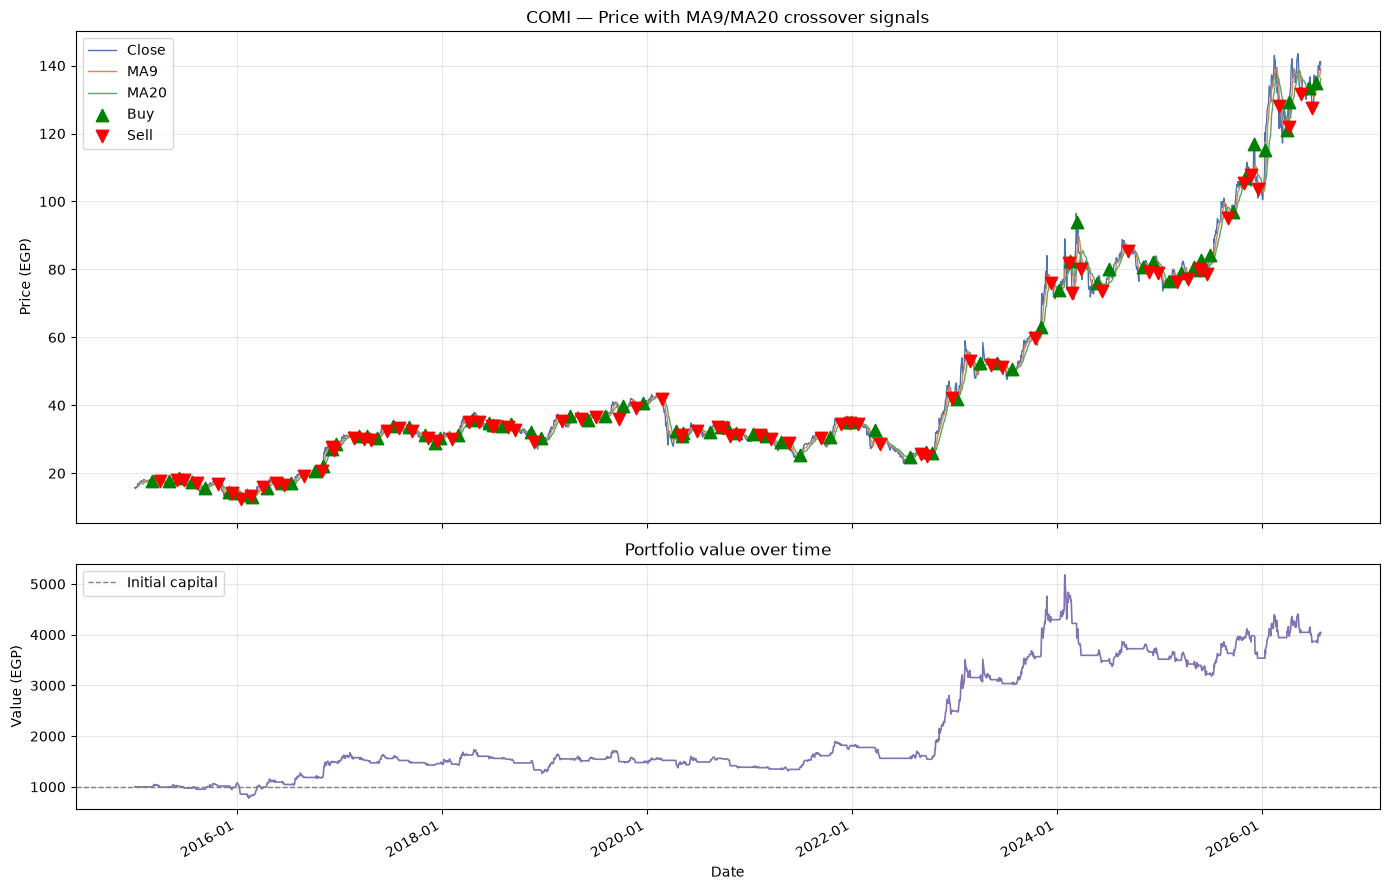

In [5]:
fig, (ax_price, ax_portfolio) = plt.subplots(
    2, 1, figsize=(14, 9), sharex=True, gridspec_kw={"height_ratios": [2, 1]}
)

# --- Price + MAs + buy/sell markers ---
ax_price.plot(df["date"], df["close"], label="Close", color="#4C72B0", linewidth=1)
ax_price.plot(df["date"], df["ma9"], label="MA9", color="#DD8452", linewidth=1)
ax_price.plot(df["date"], df["ma20"], label="MA20", color="#55A868", linewidth=1)

buys = df[df["buy_signal"]]
sells = df[df["sell_signal"]]
ax_price.scatter(buys["date"], buys["close"], marker="^", color="green", s=80, zorder=5, label="Buy")
ax_price.scatter(sells["date"], sells["close"], marker="v", color="red", s=80, zorder=5, label="Sell")

ax_price.set_title(f"{TICKER} — Price with MA9/MA20 crossover signals")
ax_price.set_ylabel("Price (EGP)")
ax_price.legend(loc="upper left")
ax_price.grid(alpha=0.3)

# --- Portfolio value ---
ax_portfolio.plot(df["date"], df["portfolio_value"], color="#8172B2", linewidth=1.2)
ax_portfolio.axhline(INITIAL_CAPITAL, color="grey", linestyle="--", linewidth=1, label="Initial capital")
ax_portfolio.set_title("Portfolio value over time")
ax_portfolio.set_ylabel("Value (EGP)")
ax_portfolio.set_xlabel("Date")
ax_portfolio.legend(loc="upper left")
ax_portfolio.grid(alpha=0.3)

ax_portfolio.xaxis.set_major_locator(mdates.AutoDateLocator())
ax_portfolio.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
fig.autofmt_xdate()

plt.tight_layout()
plt.show()
